# Lesson 2: Git & GitHub

Now that you have learned how to track changes and "commit" them on your local machine, the next step is to back them up and share them using GitHub.

In this lesson, we will:

- Create a remote repository on GitHub.
- Link your local project to that remote repository.
- Push your commits to the cloud.

---

## 2.1 Git vs. GitHub

In the previous lesson, you used Git to track changes on your local machine. Now, we will connect your work to GitHub.

**What is GitHub?**
Think of Git as the engine and GitHub as the garage:

- **Git (Local)**: The software on your computer that creates "Save Points" (commits) and tracks your history.

- **GitHub (Remote)**: A website that hosts your Git projects in the cloud. It acts as a **backup** (so you don't lose your work if your computer crashes) and a **collaboration hub** (so others can see or help with your work).

**The "Push" Workflow**
To get your work from your computer to the cloud, you follow a "Push" workflow:

1. **Local**: You commit your changes on your machine.
2. **Remote**: You "Push" those commits to GitHub. Once pushed, your files are visible on the web at your repository's URL.

In this lesson, we will link your local folder to a GitHub repository so you can sync your work with one click.

## &nbsp;&nbsp; 2.2. &nbsp;&nbsp;Create Your GitHub Account (If you do not have one already)

Before we can link our work, you need a destination.

1. Go to www.GitHub.com.
2. Click **Sign Up** and follow the prompts (you will need to verify your email).
3. **Choose a professional username**: Since GitHub is often used as a portfolio, try to pick a name you’d be comfortable sharing with future employers!

## &nbsp;&nbsp; 2.3. &nbsp;&nbsp;Connecting to a Remote Repository on GitHub

Version control really comes into its own when we begin to collaborate with other people. We already have most of the machinery we need to do this; the only thing missing is to copy changes from one repository to another.

Systems like Git allow us to move work between any two repositories. In practice, though, it’s easiest to use one copy as a central hub, and to keep it on the web rather than on someone’s laptop. Most programmers use hosting services like GitHub, Bitbucket or GitLab to hold those main copies.

Let’s start by sharing the changes we’ve made to our current project with the world. To this end we are going to create a remote repository that will be linked to our local repository.


First, set your working directory for this lesson. (**Jupyter will not remember your previous working directory when switching between notebooks**):

In [ ]:
%cd ~/my_first_git_project

### &nbsp;&nbsp; Step 1: &nbsp;&nbsp; Create a remote repository

Now that you have an account, let's build the bridge between your computer and the cloud. First, you will create the repository in Github that you will link your local repository to. 

1. On GitHub, click the + icon (top-right) → **New repository**.
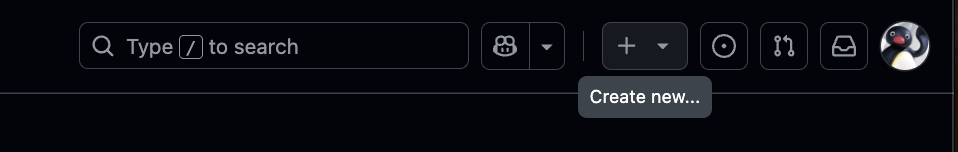
3. Name it **penguins**.
4. Click **Create repository** 

**CRITICAL**: Do **NOT** check "Initialize this repository with a README." or  We want a blank destination because our files already exist locally.

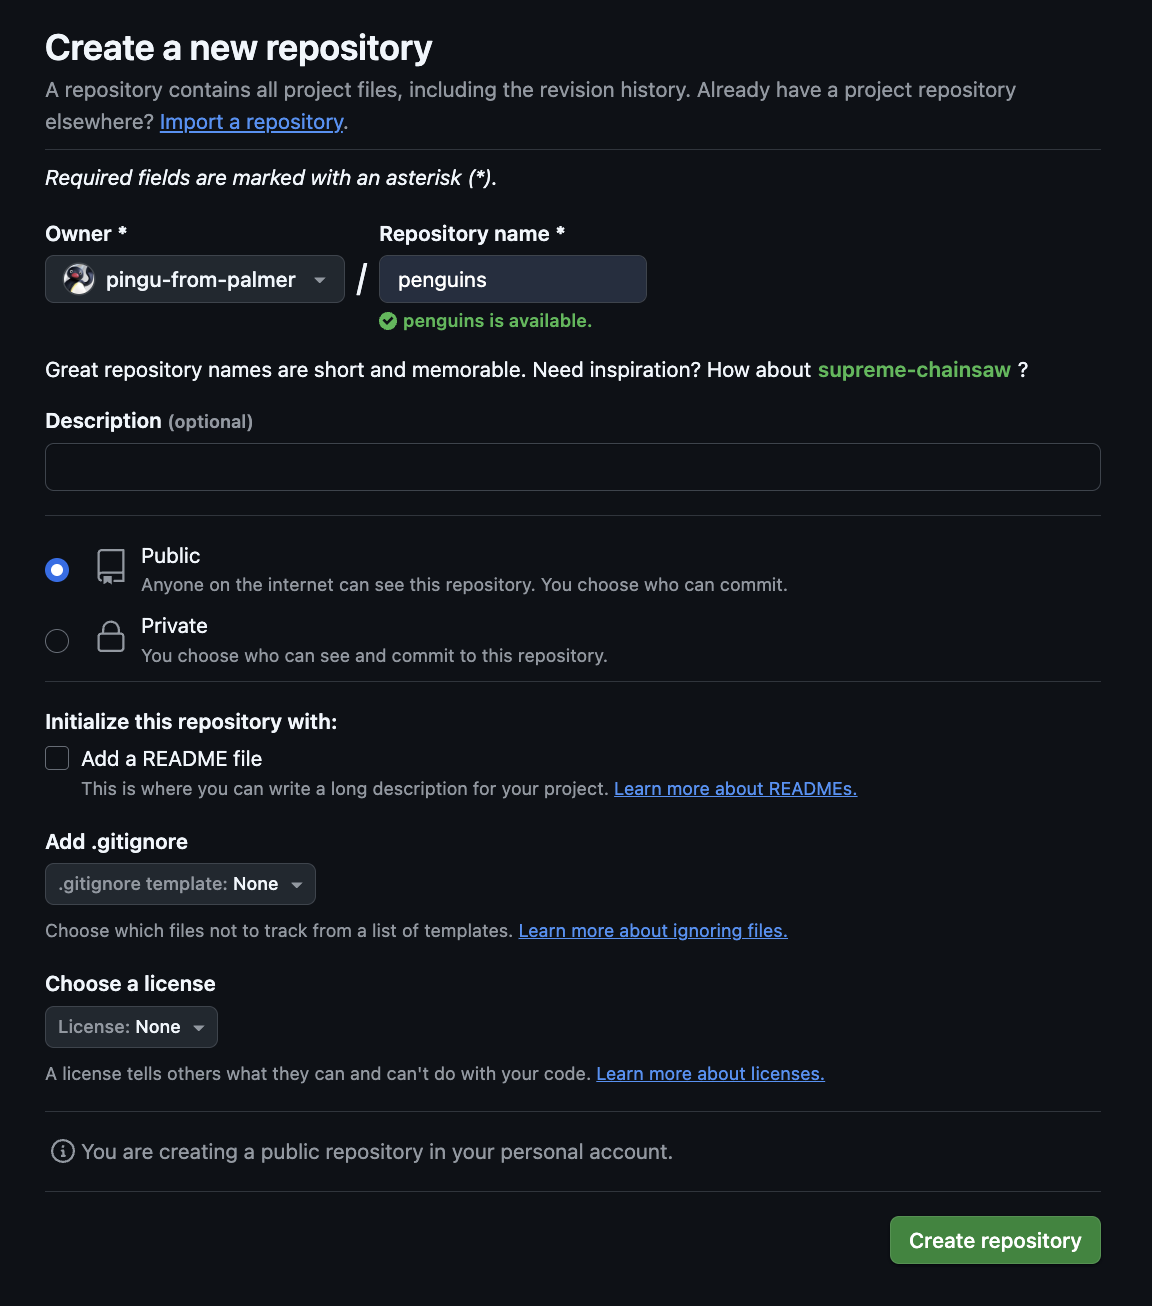

As soon as the repository is created, GitHub displays a page with a URL and some information on how to configure your local repository. 

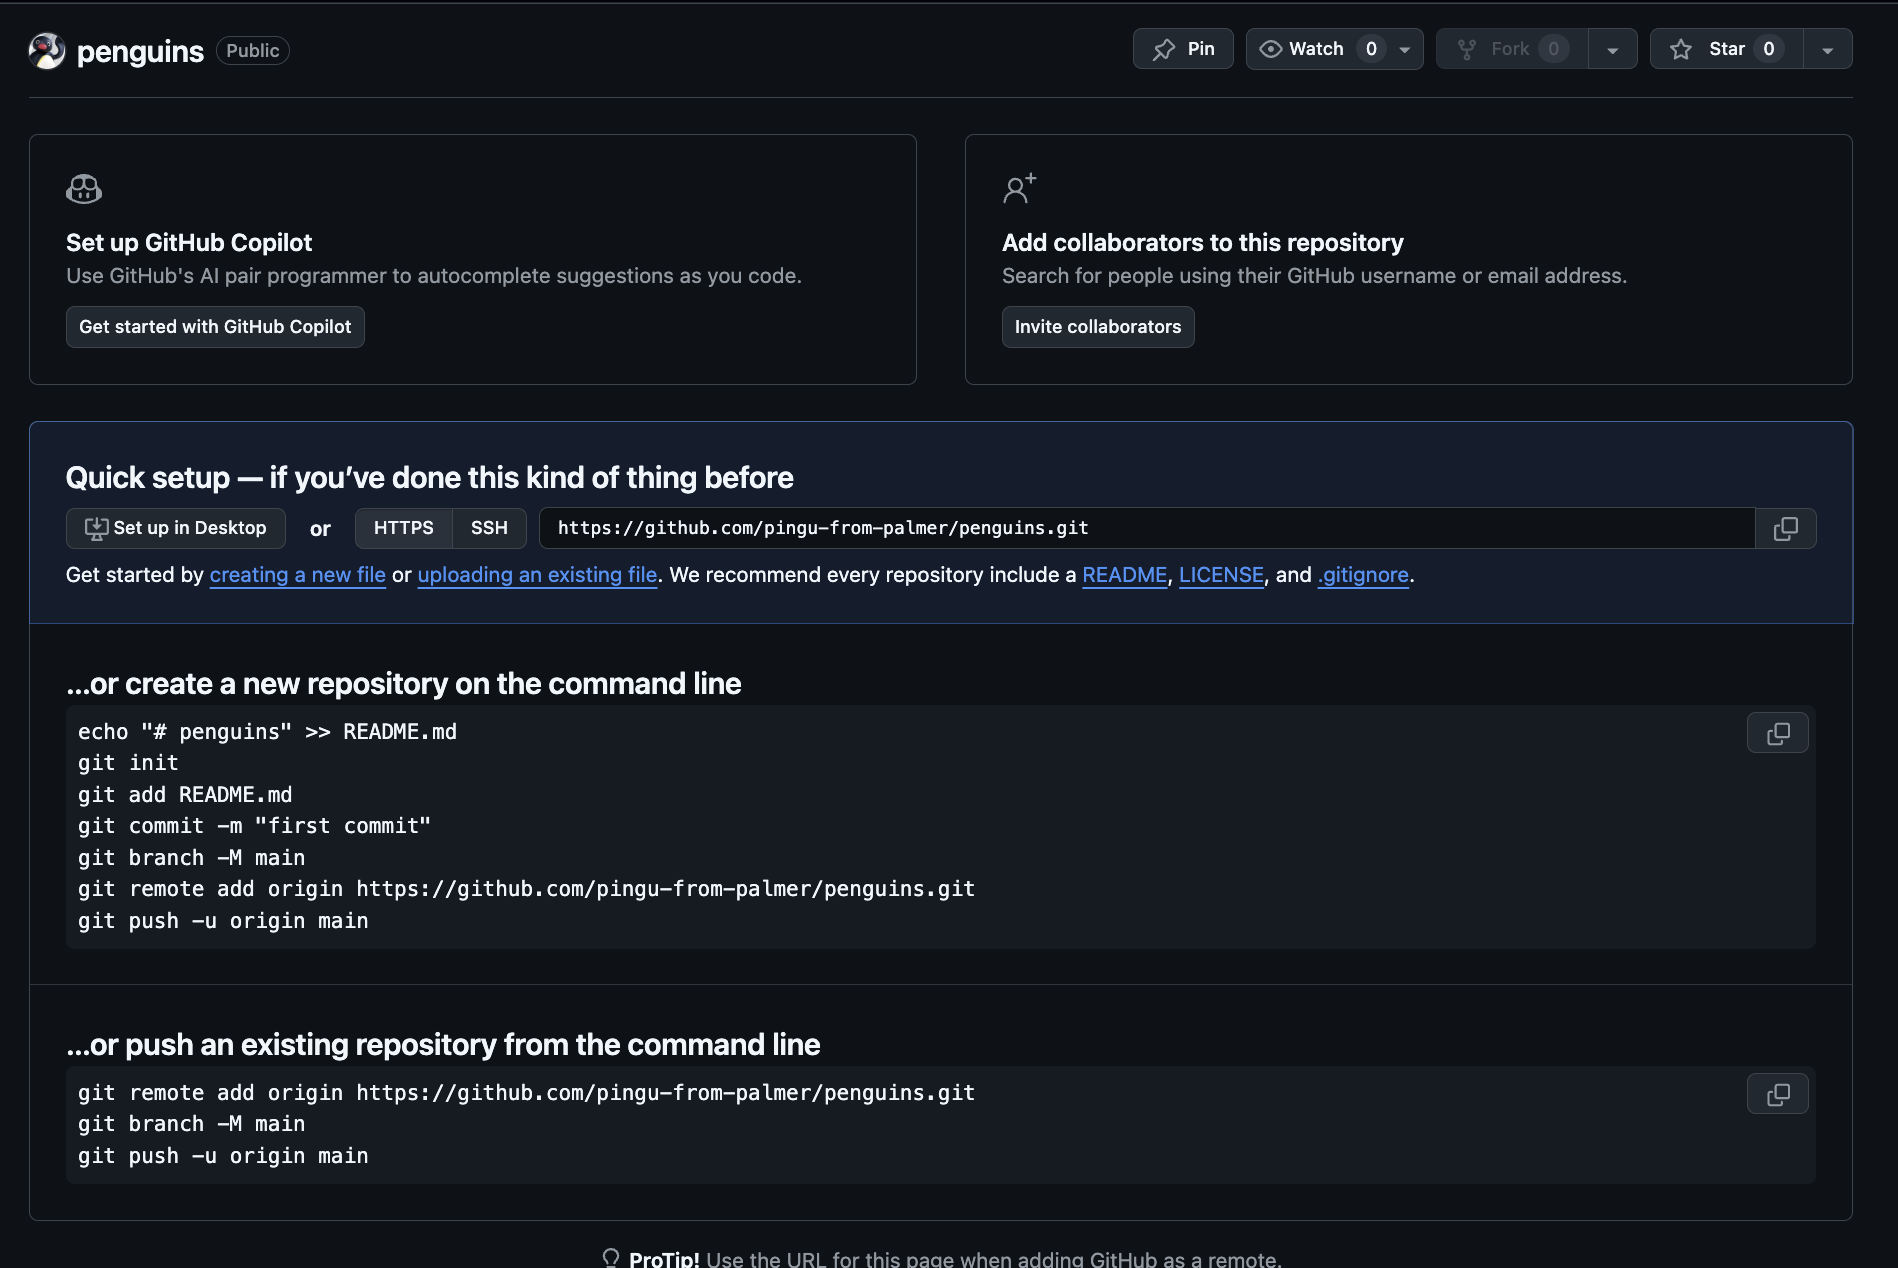

You have now created a Github repository to link your local repository to!

### &nbsp;&nbsp; Step 2: &nbsp;&nbsp;Connect the local to the remote repository  

Now we connect the two repositories. We do this by making the GitHub repository a remote for the local repository. The home page of the repository on GitHub includes the URL string we need to identify it:


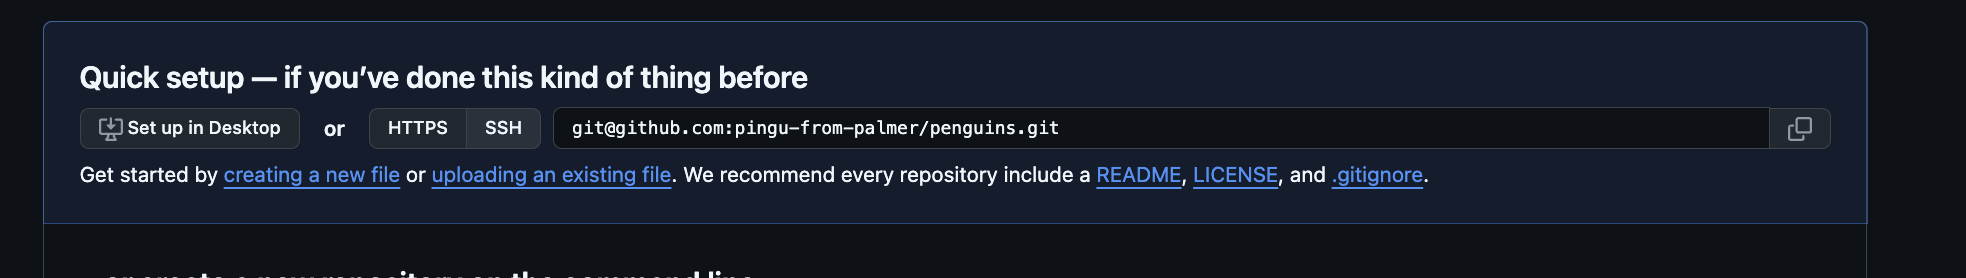

Next, copy the **SSH** (here:`git@github.com:username/penguins.git`). Replace "username" with your Github user name.  

**Now you are ready to link your local Git repo to your penguins repository.** 

1. In the menu, select **Git → Manage Remote Repositories**
2. In the dialog box that opens, fill in:
    - **Name**: origin
    - **URL**: your repo from GitHub (e.g., https://github.com/username/penguins.git)
3. Click Add
4. Save/confirm

`origin` is a local name used to refer to the remote repository. It could be called anything, but `origin` is a convention that is often used by default in git and GitHub, so it’s helpful to stick with this unless there’s a reason not to.

**Don't worry if you see an error message saying remote origin already exists!** This simply means you have already successfully linked your local repository to GitHub!  

Before you can connect to a remote repository, you needs to set up a way for your computer to **authenticate with GitHub** so it knows it’s you trying to connect to your remote repository.

---

### &nbsp;&nbsp; Step 3: &nbsp;&nbsp;SSH Background and Setup  

We are going to set up the method that is commonly used by many different services to authenticate access on the command line. This method is called **Secure Shell Protocol (SSH)**. SSH is a cryptographic network protocol that allows secure communication between computers using an otherwise insecure network.

SSH uses what is called a **key pair**. This is two keys that work together to validate access. One key is publicly known and called the **public key**, and the other key called the **private key** is kept private. Very descriptive names.

You can think of the public key as a padlock, and only you have the key (the private key) to open it. You use the public key where you want a secure method of communication, such as your GitHub account. You give this padlock, or public key, to GitHub and say “lock the communications to my account with this so that only computers that have my private key can unlock communications and send git commands as my GitHub account.”

What we will do now is the minimum required to set up the SSH keys and add the public key to a GitHub account.

**You cannot create a key pair through using the Git sidebar!** We will need to use the terminal for this. 

#### **Create an SSH key pair**

First, we will run the `ls` command to check what key pairs already exist on your instance. *They won't as you are working from a brand new instance, but it is good practice to check this if you run this from your local computer*

In [ ]:
!ls -al ~/.ssh

As predicted, you do not have an .ssh file on your instance  

Now you will open your terminal within Jupyter Lab to create the key pair. You can open your terminal here: **File → New → Terminal**

#### **Run this in your Terminal**

<blockquote>
    
**1. Navigate to your project directory**

`cd ~/my_first_git_project`

<blockquote>

**2. Create a key pair:** To create an SSH key pair you will use this command, where the `-t` option specifies which type of algorithm to use and `-C` attaches a comment to the key (here, your email):

`ssh-keygen -t ed25519 -C "kgrond@alaska.edu"`

<blockquote>

*Expected Output:*
<div style="font-family: monospace;">
Generating public/private ed25519 key pair.<br>
Enter file in which to save the key (/home/jupyter/.ssh/id_ed25519):
</div>

<blockquote>
    
**3. Press Enter**

<blockquote>

*Expected Output:*
<div style="font-family: monospace;">
Created directory '/home/jupyter/.ssh'.<br>
Enter passphrase (empty for no passphrase): 
</div>

<blockquote>
    
**4. Press Enter twice.** You are on your own private instance and don't need to password protect this key pair. 

The “identification” is actually the private key. You should never share it. The public key is appropriately named. The “key fingerprint” is a shorter version of a public key.

Now that we have generated the SSH keys, we will find the SSH files when we check.

In [ ]:
!ls -al ~/.ssh

### &nbsp;&nbsp; Step 4: &nbsp;&nbsp;Copy the public key to GitHub  

#### **Run this in your Terminal**

<blockquote>

Now we have a SSH key pair and we can run this command to check if GitHub can read our authentication. 

`ssh -T git@github.com`  

>If you see this message, type "yes"  
>`Are you sure you want to continue connecting (yes/no/[fingerprint])?`

You will see something like the below message  

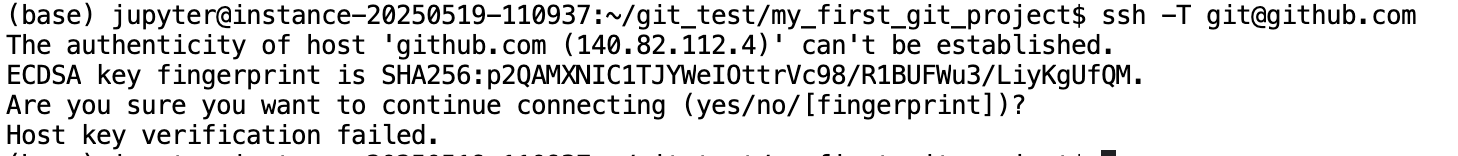

#### Right, we forgot that we need to give GitHub our public key!

First, we need to copy the public key. Be sure to include the .pub at the end, otherwise you’re looking at the private key.

In [ ]:
!cat ~/.ssh/id_ed25519.pub

Now, going to GitHub.com, **click on your profile icon** in the top right corner to get the drop-down menu. Click "Settings”,  “SSH and GPG keys”, on the left side “Access” menu. Click the “New SSH key” button on the right side. 

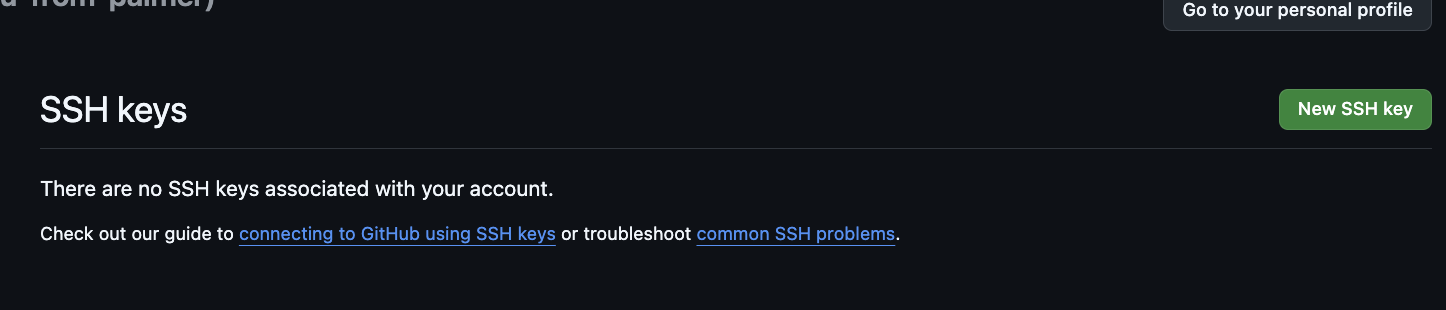

Now, you can add a name, paste your SSH key into the field (without the email address at the end), and click the “Add SSH key” to complete the setup.

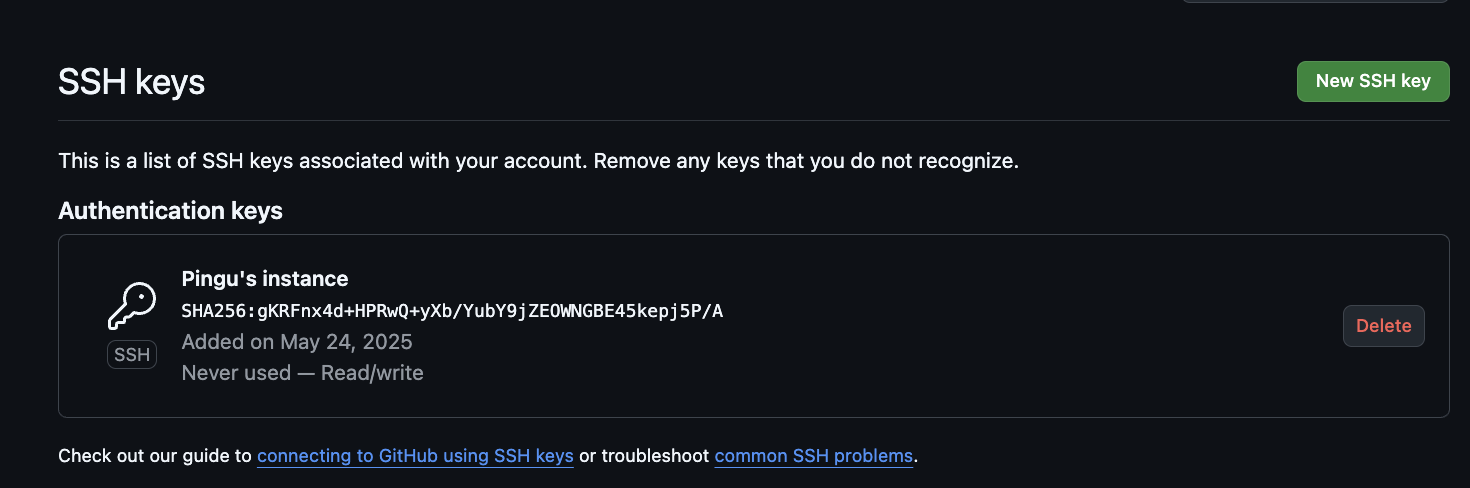

### **Run this in your Terminal**

<blockquote>

`ssh -T git@github.com`
    
You should see some variation on the below:
    
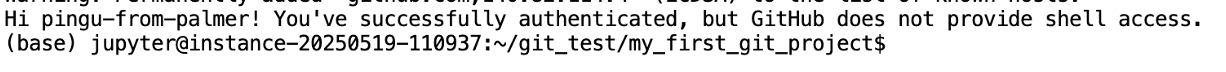

This output confirms that the SSH key works as intended. We are now ready to push our work to the remote repository.

### &nbsp;&nbsp; Step 5: &nbsp;&nbsp;Push local changes to a remote
Now that authentication is setup, we can return to your local repository and **push** the changes to your Github repository. At this point, all your changes are committed and you should have no files in the Staged, Changed, and Untracked sections.

In the top bar, click **Push to remote** in the Git menu.

✅ That’s it—your changes are now on your remote repository.  

If you look at your github penguins repository now you should see two new files: the .gitignore file and your R script. You successfully pushed your files from your local instance to a remote repository. 

7.    Pulling changes from your Github repo to your local repository.
  
We can **pull** changes from the remote repository to the local one as well. You will want to do this every time you have more changes to push to your Github, to ensure your local and Github repositories are synched. 

You can do this through: **Git → Pull from remote** 

If you click on the `Details` button in the pop-up window, you will see that your files are already up to date, which makes sense because we just pushed the same files to the remote repository.